# Практика 3 — Первая ML-модель

**Модуль 02**

---

## Что делаем в этой практике

Обучаем первый классификатор спама и честно оцениваем его:
1. Делаем правильный train/test split
2. Строим Pipeline: TF-IDF + LogReg
3. Выбираем правильные метрики для дисбаланса 87/13
4. Проверяем через DummyClassifier, что модель реально работает

---


## Настройка окружения

Запустите ячейку ниже.

In [1]:
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

nltk.download(["punkt", "punkt_tab", "wordnet", "stopwords", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"], quiet=True)

print("Всё импортировано успешно.")

Всё импортировано успешно.


---

## Задание 1 — Загрузка и подготовка данных

Повторяем шаги из Практики 1: загрузка, чистка, создание таргета.

**Что нужно сделать:**
1. Загрузите `data`, создайте `is_spam`
2. Уберите пустые строки
3. Примените функцию `clean()` из Практики 1 — создайте колонку `clean_text`
4. Выведите `df.shape` и баланс классов


In [13]:
# ТВОЙ КОД ТУТ
df=pd.read_csv ('data2.csv')
print(df.head())
print(df.shape)
print("\nБаланс классов:")
print(df['is_spam'].value_counts())

                                                text  target  len  is_spam  \
0  Go until jurong point, crazy.. Available only ...       0  111        0   
1                      Ok lar... Joking wif u oni...       0   29        0   
2  Free entry in 2 a wkly comp to win FA Cup fina...       1  155        1   
3  U dun say so early hor... U c already then say...       0   49        0   
4  Nah I don't think he goes to usf, he lives aro...       0   61        0   

                                          text_clean  
0  ['go', 'jurong', 'point', 'crazy', 'available'...  
1         ['ok', 'lar', 'joking', 'wif', 'u', 'oni']  
2  ['fre', 'entry', 'wkly', 'comp', 'win', 'fa', ...  
3  ['u', 'dun', 'say', 'early', 'hor', 'u', 'c', ...  
4  ['nah', 'think', 'go', 'usf', 'life', 'around'...  
(5572, 5)

Баланс классов:
is_spam
0    4825
1     747
Name: count, dtype: int64


In [ ]:
# ТВОЙ КОД ТУТ

---

## Задание 2 — Train / Test Split

Разделяем данные на обучающую и тестовую выборки. Это самый важный шаг перед обучением — если сделать его неправильно, метрики будут врать.

**Что нужно сделать:**
1. Разделите датасет на `X_train`, `X_test`, `y_train`, `y_test`
   - `X` — колонка `clean_text`
   - `y` — колонка `is_spam`
   - `test_size=0.2`, `random_state=42`
2. Проверьте, что доля spam одинакова в train и test
3. Выведите размеры всех четырёх переменных


In [16]:
# ТВОЙ КОД ТУТ
from sklearn.model_selection import train_test_split

# X — тексты, y — метки
X = df['text_clean']
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, )
print("Размеры выборок:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

print("\nБаланс классов в y_train:")
print(y_train.value_counts(normalize=True))
print("\nБаланс классов в y_test:")
print(y_test.value_counts(normalize=True))

Размеры выборок:
X_train: (4457,), y_train: (4457,)
X_test: (1115,), y_test: (1115,)

Баланс классов в y_train:
is_spam
0    0.866053
1    0.133947
Name: proportion, dtype: float64

Баланс классов в y_test:
is_spam
0    0.865471
1    0.134529
Name: proportion, dtype: float64


---

## Задание 3 — DummyClassifier: нижняя планка

Перед тем как обучать настоящую модель, установим нижнюю планку. Если модель не превзойдёт случайное угадывание — смысла в ней нет.

**Что нужно сделать:**
1. Создайте `DummyClassifier(strategy='stratified', random_state=42)`
2. Обучите на `X_train, y_train`
3. Посчитайте `f1_score` на тестовой выборке (по классу spam)
4. Выведите результат — это нижняя граница

In [19]:
# ТВОЙ КОД ТУТ
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

# Создаём DummyClassifier
dummy = DummyClassifier(strategy='stratified', random_state=42)

# Обучаем на тренировочных данных
dummy.fit(X_train, y_train)

# Предсказываем на тестовой выборке
dummy_f1 = f1_score(y_test, dummy.predict(X_test))



print(f"dummy f1(spam): {dummy_f1:.3f}")

dummy f1(spam): 0.178


---

## Задание 4 — Строим Pipeline: TF-IDF + LogReg

Pipeline — это цепочка шагов, которая применяется последовательно. Главный плюс: TF-IDF внутри Pipeline автоматически обучается только на train и не видит test. Утечки данных нет.

**Что нужно сделать:**
1. Создайте `Pipeline` с двумя шагами:
   - `'tfidf'`: `TfidfVectorizer(ngram_range=(1, 2), min_df=3)`
   - `'clf'`: `LogisticRegression(max_iter=2000, class_weight='balanced')`
2. Обучите Pipeline на `X_train, y_train`
3. Получите вероятности на тесте через `predict_proba`
4. Получите предсказания через порог 0.5


In [ ]:
# ТВОЙ КОД ТУТ
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Создаём Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=3)),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

# Обучаем на тренировочных данных
pipeline.fit(X_train, y_train)

# Получаем вероятности для тестовой выборки (вероятность класса 1)
proba = pipeline.predict_proba(X_test)[:, 1]   # столбец для класса spam (1)

# Получаем бинарные предсказания по порогу 0.5
pred = (proba >= 0.5).astype(int)

# (Опционально) Посчитаем F1-score для сравнения с DummyClassifier
from sklearn.metrics import f1_score
f1_spam = f1_score(y_test, pred, pos_label=1)
print(f"F1-score (spam) логистической регрессии: {f1_spam:.4f}")


F1-score (spam) логистической регрессии: 0.9103
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       965
        spam       0.91      0.91      0.91       150

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



---

## Задание 5 — Оцениваем метрики

Теперь считаем, насколько хорошо модель работает. При дисбалансе 87/13 нельзя смотреть только на accuracy — она врёт.

**Что нужно сделать:**
1. Выведите `classification_report(y_test, pred)` — посмотрите на Precision, Recall, F1 для обоих классов
2. Посчитайте и выведите `roc_auc_score(y_test, proba)`
3. Выведите `f1_score` отдельно для класса spam (для сравнения с Dummy)
4. Объясните в ячейке ниже: почему accuracy — плохая метрика для этой задачи?

> Константная модель «всё ham» даёт accuracy ~87%. Это не значит, что она хорошая. Она не поймала ни одного спама.

**Что ожидать увидеть:**
- F1(spam) ≈ 0.90–0.93
- ROC-AUC ≈ 0.97–0.99
- Recall(spam) > 0.90

In [ ]:
# ТВОЙ КОД ТУТ
#1
print(classification_report(y_test, pred, target_names=["ham", "spam"] ))
#2
roc_auc = roc_auc_score(y_test, proba)
print(f"\nROC-AUC: {roc_auc:.4f}")
#3
f1_spam = f1_score(y_test, pred, pos_label=1)
print(f"F1-score (spam): {f1_spam:.4f}")

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       965
        spam       0.91      0.91      0.91       150

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115


ROC-AUC: 0.9897
F1-score (spam): 0.9103


**Почему accuracy не подходит как основная метрика для этой задачи:**  
потому что очень сильный дисбаланс классов.

---

## Задание 6 — Confusion Matrix

Confusion matrix показывает, какие ошибки делает модель. FP и FN стоят по-разному: пропущенный спам (FN) и заблокированное обычное SMS (FP) — разные проблемы.

**Что нужно сделать:**
1. Постройте confusion matrix для предсказаний модели
2. Используйте `ConfusionMatrixDisplay` для красивого отображения
3. Подпишите классы: `display_labels=['ham', 'spam']`
4. Посчитайте и выведите:
   - Сколько spam-сообщений модель пропустила (FN)
   - Сколько ham-сообщений модель заблокировала ошибочно (FP)

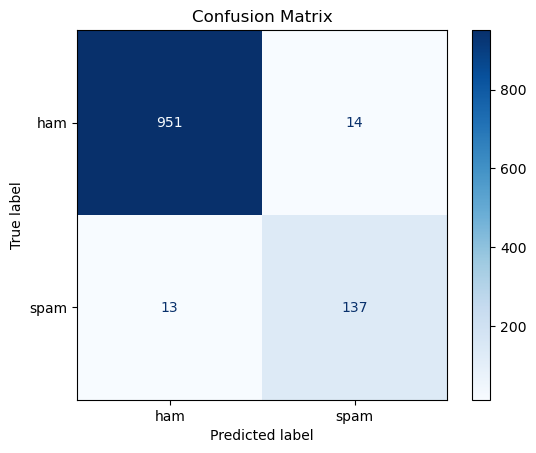

Ложноположительные (ham принят за spam) — FP: 14
Ложноотрицательные (spam пропущен) — FN: 13
Верно классифицировано ham: 951
Верно классифицировано spam: 137


In [ ]:
# ТВОЙ КОД ТУТ
# Матрица ошибок 
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])  # 0 - ham, 1 - spam

# Визуализация
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Извлекаем FP и FN для класса spam
tn, fp, fn, tp = cm.ravel()

print(f"Ложноположительные (ham принят за spam) — FP: {fp}")
print(f"Ложноотрицательные (spam пропущен) — FN: {fn}")
print(f"Верно классифицировано ham: {tn}")
print(f"Верно классифицировано spam: {tp}")

---

## Задание 7 — Сравниваем модель с Dummy

Теперь у нас есть все числа. Сравним модель с нижней планкой.

**Что нужно сделать:**
1. Выведите рядом: Dummy F1(spam) и LogReg F1(spam)
2. Посчитайте, во сколько раз LogReg лучше Dummy
3. Постройте bar chart: две полосы — Dummy и LogReg по F1(spam)

F1 (spam) DummyClassifier: 0.1778
F1 (spam) LogisticRegression: 0.9103
LogReg лучше Dummy в 5.12 раза по F1(spam)


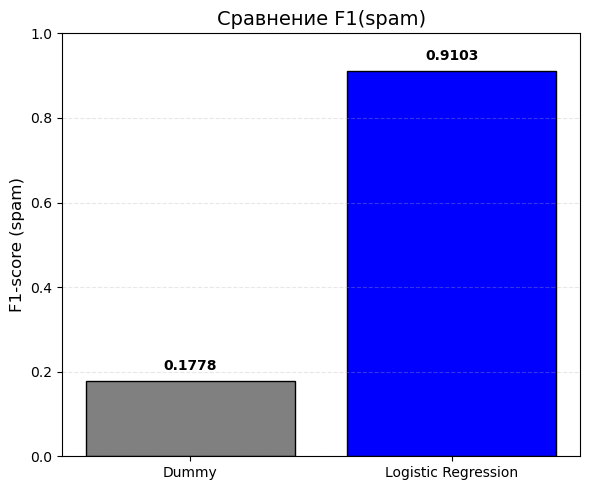

In [33]:
# ТВОЙ КОД ТУТ
f1_logreg = f1_score(y_test, pred, pos_label=1)
print(f"F1 (spam) DummyClassifier: {dummy_f1:.4f}")
print(f"F1 (spam) LogisticRegression: {f1_logreg:.4f}")

improvement = f1_logreg / dummy_f1
print(f"LogReg лучше Dummy в {improvement:.2f} раза по F1(spam)")

# Построение bar chart
plt.figure(figsize=(6, 5))
models = ['Dummy', 'Logistic Regression']
f1_scores = [dummy_f1, f1_logreg]
colors = ['gray', 'blue']

bars = plt.bar(models, f1_scores, color=colors, edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('F1-score (spam)', fontsize=12)
plt.title('Сравнение F1(spam)', fontsize=14)

# Добавление значений на столбцы
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

---

## Задание 8 — Смотрим на ошибки модели

Интересно посмотреть, какие сообщения модель классифицировала неверно. Это помогает понять её ограничения.

**Что нужно сделать:**
1. Найдите 5 примеров FN — реальный spam, но модель сказала ham
2. Найдите 5 примеров FP — реальный ham, но модель сказала spam
3. Выведите текст каждого сообщения и его настоящую метку
4. Попробуйте объяснить, почему модель ошиблась


In [35]:
# ТВОЙ КОД ТУТ

# Собираем тестовые данные с предсказаниями в один DataFrame
test_df = pd.DataFrame({
    'clean_text': X_test.reset_index(drop=True),
    'true_label': y_test.reset_index(drop=True),
    'pred_label': pred
})

# FN: реальный spam (1), предсказание ham (0)
fn_mask = (test_df['true_label'] == 1) & (test_df['pred_label'] == 0)
fn_examples = test_df[fn_mask].head(5)

# FP: реальный ham (0), предсказание spam (1)
fp_mask = (test_df['true_label'] == 0) & (test_df['pred_label'] == 1)
fp_examples = test_df[fp_mask].head(5)

print("="*60)
print("5 примеров False Negative (пропущенный спам):")
print("="*60)
for idx, row in fn_examples.iterrows():
    print(f"\nТекст: {row['clean_text'][:300]}")
    print(f"Истинная метка: spam → модель предсказала: ham")
    print("-"*40)

print("\n" + "="*60)
print("5 примеров False Positive (ошибочно заблокированный ham):")
print("="*60)
for idx, row in fp_examples.iterrows():
    print(f"\nТекст: {row['clean_text'][:300]}")
    print(f"Истинная метка: ham → модель предсказала: spam")
    print("-"*40)

5 примеров False Negative (пропущенный спам):

Текст: ['hi', 'sue', 'year', 'old', 'work', 'lapdancer', 'love', 'sex', 'text', 'live', 'bedrom', 'text', 'sue', 'textoperator', 'g', 'da', 'pmsg']
Истинная метка: spam → модель предсказала: ham
----------------------------------------

Текст: ['ringtoneking']
Истинная метка: spam → модель предсказала: ham
----------------------------------------

Текст: ['betwen', 'pm', 'cost', 'p']
Истинная метка: spam → модель предсказала: ham
----------------------------------------

Текст: ['auction', 'round', 'high', 'bid', 'next', 'maximum', 'bid', 'bid', 'send', 'bid', 'e', 'g', 'bid', 'god', 'luck']
Истинная метка: spam → модель предсказала: ham
----------------------------------------

Текст: ['email', 'alertfrom', 'jeri', 'stewartsize', 'kbsubject', 'low', 'cost', 'prescripiton', 'drvgsto', 'listen', 'email', 'cal']
Истинная метка: spam → модель предсказала: ham
----------------------------------------

5 примеров False Positive (ошибочно заблок

**Почему модель ошиблась на этих примерах?**  
Модель работает, но ошибки возникают в редких случаях, там где текст спама слишком похож на обычный.

---

## Задание 9 — Итоговая сводка

Заполните сводную таблицу с результатами. Это и есть содержимое для `README.md`.

**Что нужно сделать:**
1. Соберите все метрики в DataFrame и выведите
2. Напишите вывод: достаточно ли хороша модель? Что можно улучшить?

In [ ]:
# Соберите метрики в словарь и выведите как DataFrame
results = {
    'model':     ['DummyClassifier', 'TF-IDF + LogReg'],
    'F1(spam)':  [None, None],   # заполните
    'Recall(spam)': [None, None],
    'Precision(spam)': [None, None],
    'ROC-AUC':   [None, None],
}

### Итоговая оценка модели

**F1(spam):** *(напишите)*  
**ROC-AUC:** *(напишите)*  
**Recall(spam):** *(напишите)*

**Достаточно ли хороша модель для реального использования?** *(напишите)*

**Что можно улучшить?** *(напишите — будем делать это в Практике M3)*

---

## Итог практики 3

Если все задания выполнены:
- Есть честный stratified split (проверена доля spam в train и test)
- Обучен Pipeline(TF-IDF + LogReg) без утечек
- Посчитаны Precision, Recall, F1, ROC-AUC
- Есть сравнение с DummyClassifier
- Confusion matrix с разбором ошибок

---

**Следующий шаг:** Модуль 03 — CatBoost, ColumnTransformer, StratifiedKFold. Baseline из этой практики будет точкой отсчёта.